In [1]:
import pandas as pd

# ------------------------- STEP 1: LOAD DATA -------------------------

# Load patient demographics
patients = pd.read_csv("/root/MIMICIV/data/mimic-iv-3.1/hosp/patients.csv")

# Load hospital admissions
admissions = pd.read_csv("/root/MIMICIV/data/mimic-iv-3.1/hosp/admissions.csv")

# Load ICU stays
icustays = pd.read_csv("/root/MIMICIV/data/mimic-iv-3.1/icu/icustays.csv")

# Load diagnoses (ICD codes assigned to patients)
diagnoses = pd.read_csv("/root/MIMICIV/data/mimic-iv-3.1/hosp/diagnoses_icd.csv")

# Load prescriptions (medications administered)
prescriptions = pd.read_csv("/root/MIMICIV/data/mimic-iv-3.1/hosp/prescriptions.csv")

# Load medical procedures (ICD codes for treatments)
procedures = pd.read_csv("/root/MIMICIV/data/mimic-iv-3.1/hosp/procedures_icd.csv")

# Load ICD descriptions (for both ICD-9 and ICD-10)
icd_diagnoses = pd.read_csv("/root/MIMICIV/data/mimic-iv-3.1/hosp/d_icd_diagnoses.csv.gz")
icd_procedures = pd.read_csv("/root/MIMICIV/data/mimic-iv-3.1/hosp/d_icd_procedures.csv.gz")

# Convert ICU stay timestamps to datetime format
icustays['intime'] = pd.to_datetime(icustays['intime'], errors='coerce')
icustays['outtime'] = pd.to_datetime(icustays['outtime'], errors='coerce')


# ------------------------- STEP 2: MAP ICD CODES TO TEXT DESCRIPTIONS -------------------------

# Merge diagnoses with descriptions
diagnoses = diagnoses.merge(icd_diagnoses, on=["icd_code", "icd_version"], how="left").rename(columns={'icd_version_x': 'icd_version'})
diagnoses['diagnosis_description'] = diagnoses['long_title'].fillna("Unknown diagnosis")

# Merge procedures with descriptions
procedures = procedures.merge(icd_procedures, on=["icd_code", "icd_version"], how="left").rename(columns={'icd_version_x': 'icd_version'})
procedures['procedure_description'] = procedures['long_title'].fillna("Unknown procedure")

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [2]:
# ------------------------- STEP 3: COMPUTE AGE & MERGE DATA -------------------------

# Keep only relevant patient information
patients = patients[['subject_id', 'anchor_age', 'anchor_year', 'gender']]

# Merge patient age & demographics into event tables
admissions = admissions.merge(patients, on='subject_id', how='left', suffixes=None)
icustays = icustays.merge(patients, on='subject_id', how='left', suffixes=None)
diagnoses = diagnoses.merge(patients, on='subject_id', how='left', suffixes=None)
procedures = procedures.merge(patients, on='subject_id', how='left', suffixes=None)
prescriptions = prescriptions.merge(patients, on='subject_id', how='left', suffixes=None)

# Convert date columns to datetime
admissions['admittime'] = pd.to_datetime(admissions['admittime'])
icustays['intime'] = pd.to_datetime(icustays['intime'])
prescriptions['starttime'] = pd.to_datetime(prescriptions['starttime'])

# Compute patient age at each event
admissions['age_at_event'] = admissions['anchor_age'] + (admissions['admittime'].dt.year - admissions['anchor_year'])
icustays['age_at_event'] = icustays['anchor_age'] + (icustays['intime'].dt.year - icustays['anchor_year'])
diagnoses['age_at_event'] = diagnoses['anchor_age']
procedures['age_at_event'] = procedures['anchor_age']
prescriptions['age_at_event'] = prescriptions['anchor_age']

/tmp/ipykernel_6640/1067100215.py:7: FutureWarning: Passing 'suffixes' as a <class 'NoneType'>, is not supported and may give unexpected results. Provide 'suffixes' as a tuple instead. In the future a 'TypeError' will be raised.
  admissions = admissions.merge(patients, on='subject_id', how='left', suffixes=None)
/tmp/ipykernel_6640/1067100215.py:8: FutureWarning: Passing 'suffixes' as a <class 'NoneType'>, is not supported and may give unexpected results. Provide 'suffixes' as a tuple instead. In the future a 'TypeError' will be raised.
  icustays = icustays.merge(patients, on='subject_id', how='left', suffixes=None)
/tmp/ipykernel_6640/1067100215.py:9: FutureWarning: Passing 'suffixes' as a <class 'NoneType'>, is not supported and may give unexpected results. Provide 'suffixes' as a tuple instead. In the future a 'TypeError' will be raised.
  diagnoses = diagnoses.merge(patients, on='subject_id', how='left', suffixes=None)
/tmp/ipykernel_6640/1067100215.py:10: FutureWarning: Passing 

In [3]:
# ------------------------- STEP 4: BUILD A TABULAR DATASET -------------------------

# Aggregate data per hospitalization (`hadm_id`)
features = admissions[['subject_id', 'hadm_id', 'age_at_event', 'gender', 'admission_type', 'discharge_location']]

# Here we are referring to days
# ICU stays: Number of ICU admissions per hospitalization
# icu_summary = icustays.groupby('hadm_id').agg(
#     icu_admissions=('stay_id', 'count'),
#     icu_hours=('intime', lambda x: (x.max() - x.min()).total_seconds() / 3600)
# ).reset_index()

# Here to hours
icu_summary = icustays.assign(
    icu_duration_hours=(icustays['outtime'] - icustays['intime']).dt.total_seconds() // 3600
).groupby('hadm_id').agg(
    icu_admissions=('stay_id', 'count'),
    total_icu_hours=('icu_duration_hours', 'sum')
).reset_index()

# Diagnoses: Count number of diagnoses per hospitalization
diagnosis_summary = diagnoses.groupby('hadm_id').agg(
    num_diagnoses=('icd_code', 'count'),
    unique_diagnoses=('diagnosis_description', lambda x: list(x.unique()))
).reset_index()

# Procedures: Count number of procedures per hospitalization
procedure_summary = procedures.groupby('hadm_id').agg(
    num_procedures=('icd_code', 'count'),
    unique_procedures=('procedure_description', lambda x: list(x.unique()))
).reset_index()

# Medications: Count number of prescribed drugs per hospitalization
med_summary = prescriptions.groupby('hadm_id').agg(
    num_medications=('drug', 'count'),
    unique_medications=('drug', lambda x: list(x.unique()))
).reset_index()

# Merge all features into a single dataset
dataset = features.merge(icu_summary, on='hadm_id', how='left', suffixes=None)
dataset = dataset.merge(diagnosis_summary, on='hadm_id', how='left', suffixes=None)
dataset = dataset.merge(procedure_summary, on='hadm_id', how='left', suffixes=None)
dataset = dataset.merge(med_summary, on='hadm_id', how='left', suffixes=None)

# Fill missing values with 0 or "None" where appropriate
# To discuss whether is it properly appropriate or not.
dataset.fillna({'icu_admissions': 0, 'icu_hours': 0, 'num_diagnoses': 0, 'num_procedures': 0, 'num_medications': 0}, inplace=True)
dataset.fillna({'unique_diagnoses': 'None', 'unique_procedures': 'None', 'unique_medications': 'None'}, inplace=True)

/tmp/ipykernel_6640/3284964580.py:40: FutureWarning: Passing 'suffixes' as a <class 'NoneType'>, is not supported and may give unexpected results. Provide 'suffixes' as a tuple instead. In the future a 'TypeError' will be raised.
  dataset = features.merge(icu_summary, on='hadm_id', how='left', suffixes=None)
/tmp/ipykernel_6640/3284964580.py:41: FutureWarning: Passing 'suffixes' as a <class 'NoneType'>, is not supported and may give unexpected results. Provide 'suffixes' as a tuple instead. In the future a 'TypeError' will be raised.
  dataset = dataset.merge(diagnosis_summary, on='hadm_id', how='left', suffixes=None)
/tmp/ipykernel_6640/3284964580.py:42: FutureWarning: Passing 'suffixes' as a <class 'NoneType'>, is not supported and may give unexpected results. Provide 'suffixes' as a tuple instead. In the future a 'TypeError' will be raised.
  dataset = dataset.merge(procedure_summary, on='hadm_id', how='left', suffixes=None)
/tmp/ipykernel_6640/3284964580.py:43: FutureWarning: Pass

In [4]:
dataset.head(5)

,subject_id,hadm_id,age_at_event,gender,admission_type,discharge_location,icu_admissions,total_icu_hours,num_diagnoses,unique_diagnoses,num_procedures,unique_procedures,num_medications,unique_medications
0,10000032,22595853,52,F,URGENT,HOME,0.0,NaN,8.0,"[Portal hypertension, Other ascites, Cirrhosis...",1.0,[Percutaneous abdominal drainage],14.0,"[Furosemide, Ipratropium Bromide Neb, Potassiu..."
1,10000032,22841357,52,F,EW EMER.,HOME,0.0,NaN,8.0,[Unspecified viral hepatitis C with hepatic co...,1.0,[Percutaneous abdominal drainage],15.0,"[Furosemide, Rifaximin, Sodium Chloride 0.9% ..."
2,10000032,25742920,52,F,EW EMER.,HOSPICE,0.0,NaN,10.0,[Chronic hepatitis C without mention of hepati...,1.0,[Percutaneous abdominal drainage],28.0,"[Sodium Chloride 0.9% Flush, 0.9% Sodium Chlo..."
3,10000032,29079034,52,F,EW EMER.,HOME,1.0,9.0,13.0,"[Other iatrogenic hypotension, Chronic hepatit...",0.0,None,24.0,"[Bisacodyl, Senna, Calcium Carbonate, Raltegra..."
4,10000068,25022803,19,F,EU OBSERVATION,NaN,0.0,NaN,1.0,"[Alcohol abuse, unspecified]",1.0,[Other nonoperative respiratory measurements],0.0,None


In [5]:
dataset.columns

Index(['subject_id', 'hadm_id', 'age_at_event', 'gender', 'admission_type',
       'discharge_location', 'icu_admissions', 'total_icu_hours',
       'num_diagnoses', 'unique_diagnoses', 'num_procedures',
       'unique_procedures', 'num_medications', 'unique_medications'],
      dtype='object')

In [6]:
dataset.loc[2, 'unique_diagnoses']

['Chronic hepatitis C without mention of hepatic coma',
 'Other ascites',
 'Other dependence on machines, supplemental oxygen',
 'Cirrhosis of liver without mention of alcohol',
 'Hyperpotassemia',
 'Hyposmolality and/or hyponatremia',
 'Chronic airway obstruction, not elsewhere classified',
 'Asymptomatic human immunodeficiency virus [HIV] infection status',
 'Tobacco use disorder',
 'Diarrhea']

In [7]:
# ------------------------- STEP 5: SAVE & DISPLAY DATASET -------------------------

# Save the dataset to a CSV file for ML usage
dataset.to_csv("mimiciv_clinical_dataset.csv", index=False)


Maximum number of visits for a single patient: 238


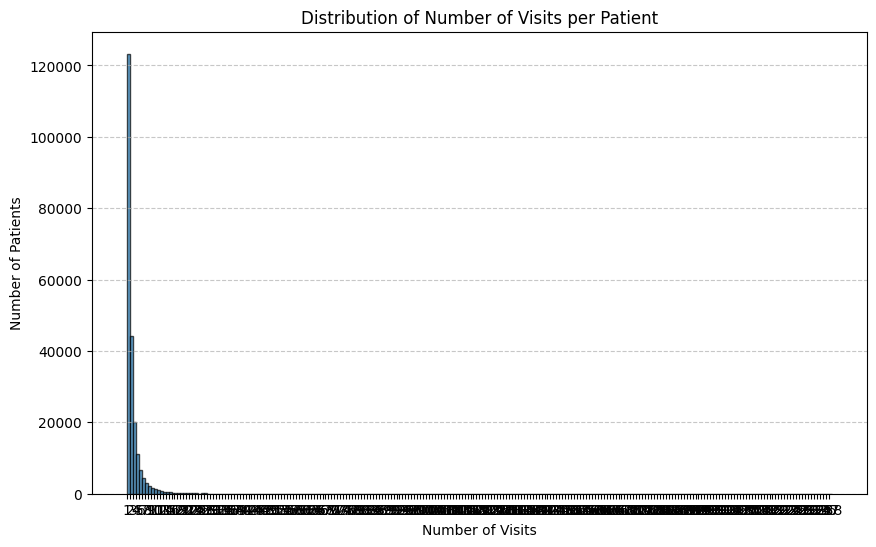

Total number of patients: 223452
Total number of patients who died: 36882 (16.51%)
Deaths during hospitalization: 11424 (30.97% of all deaths)


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset generated previously
dataset = pd.read_csv("mimiciv_clinical_dataset_tabular_death_visit.csv")

# ------------------------------------------
# 1. Distribution of number of visits per patient
# ------------------------------------------

# Count number of visits per patient
visits_per_patient = dataset.groupby('subject_id')['hadm_id'].nunique()

# Max number of visits for a single patient
max_visits = visits_per_patient.max()
print(f"Maximum number of visits for a single patient: {max_visits}")

# Plot histogram
plt.figure(figsize=(10,6))
plt.hist(visits_per_patient, bins=range(1, max_visits + 2), edgecolor='black', alpha=0.7)
plt.title("Distribution of Number of Visits per Patient")
plt.xlabel("Number of Visits")
plt.ylabel("Number of Patients")
plt.xticks(range(1, max_visits + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ------------------------------------------
# 2. Mortality Analysis and Ratios
# ------------------------------------------

# Total number of unique patients who died
patient_mortality = dataset.groupby('subject_id')['death_flag'].max().sum()

# Total deaths occurring specifically during visits
deaths_during_visit = dataset['died_during_visit'].sum()

# Calculate ratios
total_patients = dataset['subject_id'].nunique()
death_ratio = (patient_mortality / total_patients) * 100
in_hospital_death_ratio = (deaths_during_visit / patient_mortality * 100) if patient_mortality > 0 else 0

# Display the mortality results clearly
print(f"Total number of patients: {dataset['subject_id'].nunique()}")
print(f"Total number of patients who died: {int(patient_mortality)} ({patient_mortality/dataset['subject_id'].nunique():.2%})")
print(f"Deaths during hospitalization: {int(deaths_during_visit)} ({deaths_during_visit/patient_mortality:.2%} of all deaths)")


In [26]:
visits_per_patient.max()

238

In [29]:
# Identify patient(s) with the maximum number of visits
max_visits_patient = visits_per_patient[visits_per_patient == visits_per_patient.max()]
print("Patient(s) with the maximum number of visits:")
print(max_patient := max(visits_per_patient))
visits_per_patient[visits_per_patient == visits_per_patient.max()]

Patient(s) with the maximum number of visits:
238


subject_id
15496609    238
Name: hadm_id, dtype: int64

In [22]:
# Select only rows for patient 15496609
patient_data = dataset[dataset['subject_id'] == '15496609']



In [34]:
dataset.head()

,subject_id,hadm_id,age_at_event,gender,admission_type,admission_category,discharge_location,death_flag,age_at_death,died_during_visit,days_from_last_visit_to_death,days_until_next_visit,icu_admissions,icu_days,num_diagnoses,diagnosis_list,num_procedures,procedure_list,num_medications,medication_list
0,10000032,22595853,52,F,URGENT,EMERGENCY,HOME,1,52.0,0,32.0,50.0,0.0,0.0,8.0,"['Portal hypertension', 'Other ascites', 'Cirr...",1.0,['Percutaneous abdominal drainage'],14.0,"['Furosemide', 'Ipratropium Bromide Neb', 'Pot..."
1,10000032,22841357,52,F,EW EMER.,EMERGENCY,HOME,1,52.0,0,32.0,25.0,0.0,0.0,8.0,['Unspecified viral hepatitis C with hepatic c...,1.0,['Percutaneous abdominal drainage'],15.0,"['Furosemide', 'Rifaximin', 'Sodium Chloride 0..."
2,10000032,29079034,52,F,EW EMER.,EMERGENCY,HOME,1,52.0,0,32.0,11.0,1.0,0.0,13.0,"['Other iatrogenic hypotension', 'Chronic hepa...",0.0,None,24.0,"['Bisacodyl', 'Senna', 'Calcium Carbonate', 'R..."
3,10000032,25742920,52,F,EW EMER.,EMERGENCY,HOSPICE,1,52.0,0,32.0,-1.0,0.0,0.0,10.0,['Chronic hepatitis C without mention of hepat...,1.0,['Percutaneous abdominal drainage'],28.0,"['Sodium Chloride 0.9% Flush', '0.9% Sodium C..."
4,10000068,25022803,19,F,EU OBSERVATION,NORMAL,NaN,0,NaN,0,NaN,-1.0,0.0,0.0,1.0,"['Alcohol abuse, unspecified']",1.0,['Other nonoperative respiratory measurements'],0.0,None


In [38]:
dataset[dataset['subject_id']==15496609]

,subject_id,hadm_id,age_at_event,gender,admission_type,admission_category,discharge_location,death_flag,age_at_death,died_during_visit,days_from_last_visit_to_death,days_until_next_visit,icu_admissions,icu_days,num_diagnoses,diagnosis_list,num_procedures,procedure_list,num_medications,medication_list
299564,15496609,20495098,57,M,EU OBSERVATION,NORMAL,NaN,0,NaN,0,NaN,242.0,0.0,0.0,1.0,"['Alcohol abuse, unspecified']",0.0,None,0.0,None
299565,15496609,29558470,58,M,EU OBSERVATION,NORMAL,NaN,0,NaN,0,NaN,22.0,0.0,0.0,2.0,"['Altered mental status', 'Alcohol abuse, unsp...",2.0,"['Computerized axial tomography of head', 'Oth...",0.0,None
299566,15496609,27670095,58,M,EU OBSERVATION,NORMAL,NaN,0,NaN,0,NaN,2.0,0.0,0.0,3.0,"['Altered mental status', 'Alcohol abuse, unsp...",2.0,"['Routine chest x-ray, so described', 'Other n...",0.0,None
299567,15496609,22716732,58,M,EU OBSERVATION,NORMAL,NaN,0,NaN,0,NaN,33.0,0.0,0.0,1.0,"['Alcohol abuse, unspecified']",0.0,None,0.0,None
299568,15496609,29187036,58,M,EU OBSERVATION,NORMAL,NaN,0,NaN,0,NaN,18.0,0.0,0.0,1.0,"['Alcohol abuse, unspecified']",0.0,None,0.0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299797,15496609,24400269,68,M,EU OBSERVATION,NORMAL,NaN,0,NaN,0,NaN,9.0,0.0,0.0,2.0,"['Alcohol abuse with intoxication, unspecified...",0.0,None,0.0,None
299798,15496609,27808353,68,M,EU OBSERVATION,NORMAL,NaN,0,NaN,0,NaN,57.0,0.0,0.0,2.0,"['Alcohol abuse with intoxication, unspecified...",0.0,None,0.0,None
299799,15496609,22017230,68,M,EU OBSERVATION,NORMAL,NaN,0,NaN,0,NaN,3.0,0.0,0.0,5.0,"['Alcohol abuse with intoxication, unspecified...",0.0,None,0.0,None
299800,15496609,24958468,68,M,EU OBSERVATION,NORMAL,NaN,0,NaN,0,NaN,33.0,0.0,0.0,3.0,"['Alcohol abuse with intoxication, unspecified...",0.0,None,0.0,None


Let's exclude this patient from our dataset

Maximum number of visits for a single patient: 238


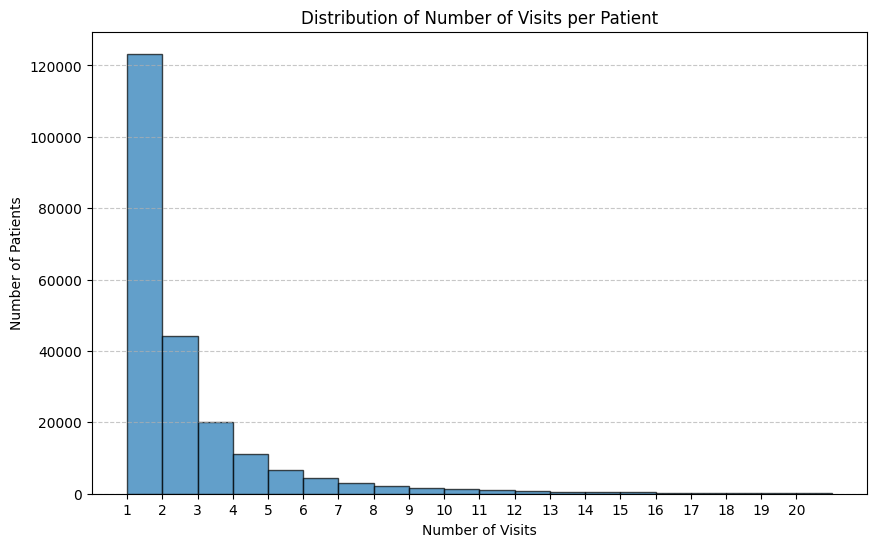

In [41]:
# ------------------------------------------
# 1. Distribution of number of visits per patient
# ------------------------------------------

# Count number of visits per patient
visits_per_patient = dataset.groupby('subject_id')['hadm_id'].nunique()

# Max number of visits for a single patient
max_visits = visits_per_patient.max()
print(f"Maximum number of visits for a single patient: {max_visits}")

# Plot histogram
x_range = 20
plt.figure(figsize=(10,6))
plt.hist(visits_per_patient, bins=range(1, x_range + 2), edgecolor='black', alpha=0.7)
plt.title("Distribution of Number of Visits per Patient")
plt.xlabel("Number of Visits")
plt.ylabel("Number of Patients")
plt.xticks(range(1, x_range + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
dataset = pd.read_csv("mimiciv_clinical_dataset_tabular_death_visit.csv")

# Count admission categories
admission_counts = dataset['admission_category'].value_counts()

# Display counts
print("Admission category counts:")
print(admission_counts := dataset['admission_category'].value_counts())


Admission category counts:
NORMAL       291667
EMERGENCY    254361
Name: admission_category, dtype: int64


In [3]:
len(dataset) # 291667 + 254361

546028

In [5]:
dataset.head(5)

,subject_id,hadm_id,age_at_event,gender,admission_type,admission_category,discharge_location,death_flag,age_at_death,died_during_visit,days_from_last_visit_to_death,days_until_next_visit,icu_admissions,icu_days,num_diagnoses,diagnosis_list,num_procedures,procedure_list,num_medications,medication_list
0,10000032,22595853,52,F,URGENT,EMERGENCY,HOME,1,52.0,0,32.0,50.0,0.0,0.0,8.0,"['Portal hypertension', 'Other ascites', 'Cirr...",1.0,['Percutaneous abdominal drainage'],14.0,"['Furosemide', 'Ipratropium Bromide Neb', 'Pot..."
1,10000032,22841357,52,F,EW EMER.,EMERGENCY,HOME,1,52.0,0,32.0,25.0,0.0,0.0,8.0,['Unspecified viral hepatitis C with hepatic c...,1.0,['Percutaneous abdominal drainage'],15.0,"['Furosemide', 'Rifaximin', 'Sodium Chloride 0..."
2,10000032,29079034,52,F,EW EMER.,EMERGENCY,HOME,1,52.0,0,32.0,11.0,1.0,0.0,13.0,"['Other iatrogenic hypotension', 'Chronic hepa...",0.0,None,24.0,"['Bisacodyl', 'Senna', 'Calcium Carbonate', 'R..."
3,10000032,25742920,52,F,EW EMER.,EMERGENCY,HOSPICE,1,52.0,0,32.0,-1.0,0.0,0.0,10.0,['Chronic hepatitis C without mention of hepat...,1.0,['Percutaneous abdominal drainage'],28.0,"['Sodium Chloride 0.9% Flush', '0.9% Sodium C..."
4,10000068,25022803,19,F,EU OBSERVATION,NORMAL,NaN,0,NaN,0,NaN,-1.0,0.0,0.0,1.0,"['Alcohol abuse, unspecified']",1.0,['Other nonoperative respiratory measurements'],0.0,None
